# 📌 Submission Guidelines

### ✅ File Naming Rule  
Submit your notebook with the following format:

`StudentID_YourFullName_LABXX.ipynb`

or

`StudentID_YourFullName_LABXX.html`

**Examples (Correct):**
- `21113456_NguyenVanA_LAB01.ipynb`
- `19122233_TranThiB_LAB02.ipynb`

**Examples (Wrong → 0 points):**
- `Lab01.ipynb`
- `YourName.ipynb`
- `20123456.ipynb`
- `Lab01.pdf`

---

### 📌 Grading Policy

- ❌ Wrong filename format, missing submission, or plagiarism (code identical to others) → 0 points

- ⚠️ Submitting a file without results, incomplete work, or only the assignment description → Maximum 4 points

- ✅ Correct filename + Completed results → Graded normally based on assignment quality (accuracy, clarity, and originality)  
### Note:
- AI assistance is allowed, but you must write the code yourself. All submissions will be checked for originality.

---



## 🧪 NLP LAB  
### Attention Mechanism – From Bottleneck to Intelligent Representations

## TITLE

**Attention Mechanism Lab:** Understanding and Implementing Attention in Sequence Models

## LEARNING OBJECTIVES

After this lab session, students will:

### 🧠 Conceptual Understanding

- Understand the limitations of **fixed-size vector representations** (sequence → vector)
- Understand the **information bottleneck problem**
- Understand the core idea of the **Attention mechanism**
- Understand the roles of:
  - **Query**
  - **Key**
  - **Value**
- Understand why Attention improves model performance

### 💻 Practical Skills

Students will be able to:

- Build a sequence model **without Attention**
- Implement the **Attention mechanism step by step**
- Integrate Attention into an existing model
- Visualize **attention weights**

## 🎯 Intuition

### ❌ Without Attention


"I love deep learning very much" → Encoder → Prediction


👉 **Problem:**

- All information is compressed into one
- Leads to **information loss**, especially for long sequences

### ✅ With Attention


"I love deep learning very much" → Encoder outputs (multiple vectors) → Attention (focus on relevant parts) → Weighted combination → Prediction


👉 **Key Idea:**
> the model **selectively focuses on important parts of the sequence**.

## 💡 Takeaway

- Without Attention → **Information bottleneck**
- With Attention → **Dynamic, context-aware representation**

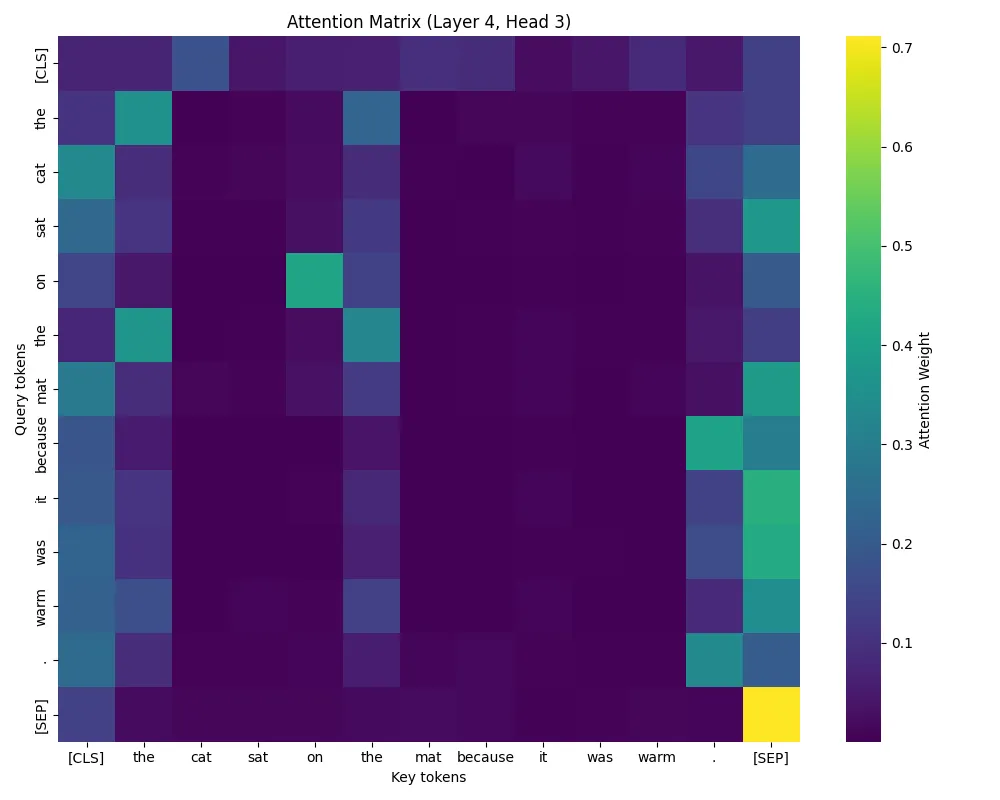

## SHORT THEORY (Detailed & Intuitive)

### Sequence-to-Vector Problem

Traditional **RNN/LSTM** models compress a sequence into a single vector:


$$\text{sequence} \rightarrow \mathbf{h}$$

Example: I love deep learning very much" → Encoder → h (single vector)


> ⚠️ Problem:
> - All information is forced into **one fixed-size vector**
> - Important details may be **lost**, especially in long sentences



### Bottleneck Problem

The vector $\mathbf{h}$ acts as a **bottleneck**:

- Limited capacity  
- Cannot store all information  

> ❗ The longer or more complex the sentence, the more severe the information loss.



### Core Idea of Attention

> 💡 Instead of compressing everything → **select relevant information dynamically**

At each step, the model:

- Looks at **all encoder outputs**
- Chooses what to focus on

### Query – Key – Value (Intuition)

| Component | Meaning | Example |
|----------|--------|--------|
| Query | What we are looking for | Current decoding step |
| Key | Representation of each word | Encoder hidden states |
| Value | Actual information | Same as key (often) |


### Step-by-Step Attention (Numerical Example)

Suppose we have 3 words → 3 vectors:

$$
K = [k_1, k_2, k_3], \quad V = [v_1, v_2, v_3]
$$

Query:

$$
q
$$

#### Step 1️⃣: Compute scores

Use dot product:

$$
score_i = q \cdot k_i
$$

Example:

$$
score = [2.0,\ 1.0,\ 0.1]
$$


#### Step 2️⃣: Apply Softmax
$$
weights = \text{softmax}(score)
$$

Result:

$$
weights \approx [0.65,\ 0.24,\ 0.11]
$$

> 💡 Higher score → higher attention weight

#### Step 3️⃣: Compute output

$$
output = \sum_i weight_i \cdot v_i
$$

$$
output = 0.65v_1 + 0.24v_2 + 0.11v_3
$$

> 🎯 The model focuses mostly on $v_i$

### Intuition Example (Sentence)

Sentence: "I love deep learning very much"

Task: predict next word

If the model focuses on:

- "learning" → high weight  
- "very" → medium weight  
- "I" → low weight  

→ Better prediction
### ✅ With Attention

Instead of using a single vector, the model keeps **all hidden states**:

\[
[h_1, h_2, h_3, ..., h_n]
\]

At prediction time, the model asks:

> 💡 "Which words should I focus on?"

### 🎯 Intuition Example

| Word | Importance | Attention Weight |
|------|----------|------------------|
| learning | Very important | 0.6 |
| very | Moderately important | 0.3 |
| I | Not important | 0.1 |

### 💡 Key Insight

- Not all words contribute equally  
- Attention assigns **dynamic importance weights**  
- The model focuses on **relevant information**

### 🚀 Why This Improves Prediction

To predict the next word (e.g., *"much"*):

- Focusing on **"learning" + "very"** → correct context  
- Ignoring irrelevant words → better accuracy  

### 🧠 Deep Understanding

> Attention is essentially a **weighted memory retrieval mechanism**

- The sequence = memory  
- Query = what we are looking for  
- Keys = indexing system  
- Values = actual stored information  


### 🔥 Final Takeaway

- Without Attention → **fixed representation + information bottleneck**
- With Attention → **dynamic, context-aware representation**

> ❗ Attention does not add new information  
> It **selects and re-weights existing information intelligently**


### Key Insight

- Attention assigns **importance weights** to each word  
- The model does **not treat all words equally**


### Summary

| Without Attention | With Attention |
|------------------|---------------|
| Single vector | Multiple vectors |
| Information loss | Selective focus |
| Fixed representation | Dynamic representation |


> 🚀 Attention allows models to **adaptively focus on relevant parts of the input**, solving the bottleneck problem.


# code sample

In [ ]:
!pip install datasets==2.18.0

## SIMPLE TOY DATASET

In [ ]:
from datasets import load_dataset

dataset = load_dataset("uitnlp/vietnamese_students_feedback")

In [ ]:
print(dataset["train"])

Dataset({
    features: ['sentence', 'sentiment', 'topic'],
    num_rows: 11426
})


In [ ]:
train_set = dataset["train"]
test_set = dataset["test"]

In [ ]:
def tokenize(text):
    return text.lower().split()

tokens_train = [tokenize(text) for text in train_set["sentence"]]
labels_train = train_set["sentiment"]


In [ ]:
from collections import Counter

counter = Counter()

for sentence in tokens_train:
    counter.update(sentence)

vocab = [w for w, c in counter.items() if c >= 2]
word2idx = {w:i+1 for i,w in enumerate(vocab)}  # +1 để dành cho padding
word2idx["<PAD>"] = 0

In [ ]:
max_len = 20

def encode(sentence):
    ids = [word2idx.get(w, 0) for w in sentence]
    ids = ids[:max_len]
    ids += [0] * (max_len - len(ids))
    return ids

data = [encode(s) for s in tokens_train]

In [ ]:
data[0]

[1, 2, 3, 4, 5, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [ ]:
import torch

X = torch.tensor(data)
y = torch.tensor(labels_train)

In [ ]:
def predict(text,model):
    tok = tokenize(text)
    ids = encode(tok)
    x = torch.tensor([ids], dtype=torch.long)

    model.eval()

    out = model(x)
    pred = torch.argmax(out, dim=1).item()

    print("Text:", text)
    print("Prediction:", pred)

## BASELINE (NO ATTENTION)

In [ ]:
import torch
import torch.nn as nn

class SimpleModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.fc = nn.Linear(embed_dim, 3)

    def forward(self, x):
        emb = self.embedding(x)        # (seq_len, dim)
        pooled = emb.mean(dim=1)       # ❗ compress
        out = self.fc(pooled)
        return out

In [ ]:
model = SimpleModel(len(word2idx), 50)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 50
batch_size = 32

for epoch in range(epochs):
    total_loss = 0
    correct = 0

    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size]
        yb = y[i:i+batch_size]

        out = model(xb)
        loss = criterion(out, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = out.argmax(dim=1)
        correct += (preds == yb).sum().item()

    acc = correct / len(X)

    print(f"Epoch {epoch} | Loss: {total_loss:.4f} | Acc: {acc:.4f}")

Epoch 0 | Loss: 283.0575 | Acc: 0.6592
Epoch 1 | Loss: 184.4482 | Acc: 0.8299
Epoch 2 | Loss: 146.8329 | Acc: 0.8642
Epoch 3 | Loss: 129.1330 | Acc: 0.8813
Epoch 4 | Loss: 118.5360 | Acc: 0.8904
Epoch 5 | Loss: 111.3896 | Acc: 0.9002
Epoch 6 | Loss: 106.1823 | Acc: 0.9036
Epoch 7 | Loss: 102.1711 | Acc: 0.9073
Epoch 8 | Loss: 98.9472 | Acc: 0.9106
Epoch 9 | Loss: 96.2670 | Acc: 0.9125
Epoch 10 | Loss: 93.9768 | Acc: 0.9137
Epoch 11 | Loss: 91.9757 | Acc: 0.9163
Epoch 12 | Loss: 90.1952 | Acc: 0.9176
Epoch 13 | Loss: 88.5879 | Acc: 0.9191
Epoch 14 | Loss: 87.1201 | Acc: 0.9197
Epoch 15 | Loss: 85.7674 | Acc: 0.9210
Epoch 16 | Loss: 84.5117 | Acc: 0.9214
Epoch 17 | Loss: 83.3394 | Acc: 0.9225
Epoch 18 | Loss: 82.2399 | Acc: 0.9237
Epoch 19 | Loss: 81.2050 | Acc: 0.9244
Epoch 20 | Loss: 80.2280 | Acc: 0.9253
Epoch 21 | Loss: 79.3033 | Acc: 0.9266
Epoch 22 | Loss: 78.4265 | Acc: 0.9265
Epoch 23 | Loss: 77.5937 | Acc: 0.9274
Epoch 24 | Loss: 76.8015 | Acc: 0.9280
Epoch 25 | Loss: 76.0471 | 

In [ ]:
predict("tôi thích học môn này",model)
predict("nó dở quá",model)
predict("môn học này rất hay",model)
predict("giảng viên dạy chán",model)

Text: tôi thích học môn này
Prediction: 1
Text: nó dở quá
Prediction: 0
Text: môn học này rất hay
Prediction: 2
Text: giảng viên dạy chán
Prediction: 0


## IMPLEMENT ATTENTION (CORE)

### Step 1: Compute scores

In [ ]:
def attention_scores(query, keys):
    # query: (batch_size, embed_dim)
    # keys: (batch_size, max_len, embed_dim)
    # For batched dot product: (B, S, D) @ (B, D, 1) -> (B, S, 1)
    return torch.bmm(keys, query.unsqueeze(-1)).squeeze(-1) # -> (batch_size, max_len)

### Step 2: Softmax

In [ ]:
def attention_weights(scores):
    # scores: (batch_size, max_len)
    # Apply softmax across max_len dimension for each batch item
    return torch.softmax(scores, dim=1)

### Step 3: Weighted sum

In [ ]:
def attention_output(weights, values):
    # weights: (batch_size, max_len)
    # values: (batch_size, max_len, embed_dim)
    # Unsqueeze weights to (batch_size, max_len, 1) for element-wise multiplication
    # Sum over max_len dimension (dim=1) to get (batch_size, embed_dim)
    return torch.sum(weights.unsqueeze(-1) * values, dim=1)

### combine

In [ ]:
def attention(query, keys, values):
    scores = attention_scores(query, keys)
    weights = attention_weights(scores)
    output = attention_output(weights, values)
    return output, weights

### Full model with attention

In [ ]:
class AttentionModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.fc = nn.Linear(embed_dim, 3) # Changed from 2 to 3 for 3 classes

    def forward(self, x):
        # x: (batch_size, max_len)
        emb = self.embedding(x)   # (batch_size, max_len, embed_dim)

        # Query should be per item in the batch, so average over max_len (dim=1)
        query = emb.mean(dim=1)   # (batch_size, embed_dim)

        output, weights = attention(query, emb, emb)

        out = self.fc(output) # output is (batch_size, embed_dim)
        return out, weights

### Training loop

In [ ]:
model = AttentionModel(len(word2idx), 50)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

epochs = 50
batch_size = 32

for epoch in range(epochs):
    total_loss = 0
    correct = 0

    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size]
        yb = y[i:i+batch_size]

        out, _ = model(xb) # Unpack output and weights
        loss = criterion(out, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = out.argmax(dim=1)
        correct += (preds == yb).sum().item()

    acc = correct / len(X)

    print(f"Epoch {epoch} | Loss: {total_loss:.4f} | Acc: {acc:.4f}")

Epoch 0 | Loss: 222.2127 | Acc: 0.7135
Epoch 1 | Loss: 118.4740 | Acc: 0.8899
Epoch 2 | Loss: 87.2348 | Acc: 0.9215
Epoch 3 | Loss: 68.9551 | Acc: 0.9407
Epoch 4 | Loss: 57.6111 | Acc: 0.9516
Epoch 5 | Loss: 48.5623 | Acc: 0.9612
Epoch 6 | Loss: 42.7601 | Acc: 0.9669
Epoch 7 | Loss: 37.8660 | Acc: 0.9712
Epoch 8 | Loss: 35.3456 | Acc: 0.9739
Epoch 9 | Loss: 31.0570 | Acc: 0.9766
Epoch 10 | Loss: 29.8463 | Acc: 0.9776
Epoch 11 | Loss: 28.1955 | Acc: 0.9790
Epoch 12 | Loss: 25.9509 | Acc: 0.9827
Epoch 13 | Loss: 24.4647 | Acc: 0.9830
Epoch 14 | Loss: 23.9562 | Acc: 0.9834
Epoch 15 | Loss: 24.0025 | Acc: 0.9825
Epoch 16 | Loss: 25.6860 | Acc: 0.9815
Epoch 17 | Loss: 21.8246 | Acc: 0.9844
Epoch 18 | Loss: 19.6601 | Acc: 0.9860
Epoch 19 | Loss: 19.2855 | Acc: 0.9864
Epoch 20 | Loss: 17.7426 | Acc: 0.9877
Epoch 21 | Loss: 19.3360 | Acc: 0.9864
Epoch 22 | Loss: 22.3799 | Acc: 0.9851
Epoch 23 | Loss: 18.0726 | Acc: 0.9877
Epoch 24 | Loss: 16.0184 | Acc: 0.9897
Epoch 25 | Loss: 15.2176 | Acc: 0

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


def predict_attention_model(text,model):
    tok = tokenize(text)
    ids = encode(tok)
    x = torch.tensor([ids], dtype=torch.long)

    model.eval()

    out, weights = model(x)
    pred = torch.argmax(out, dim=1).item()

    print("Text:", text)
    print("Prediction:", pred)
    print("Attention weights:", weights)


    plt.figure(figsize=(10, 6)) # Set a larger figure size
    sns.heatmap(weights.detach(), annot=True)
    plt.show()
    print("===========================================")

Text: tôi thích học môn này
Prediction: 1
Attention weights: tensor([[2.1110e-01, 3.2226e-03, 1.4610e-01, 4.1497e-04, 4.9935e-05, 4.2607e-02,
         4.2607e-02, 4.2607e-02, 4.2607e-02, 4.2607e-02, 4.2607e-02, 4.2607e-02,
         4.2607e-02, 4.2607e-02, 4.2607e-02, 4.2607e-02, 4.2607e-02, 4.2607e-02,
         4.2607e-02, 4.2607e-02]], grad_fn=<SoftmaxBackward0>)


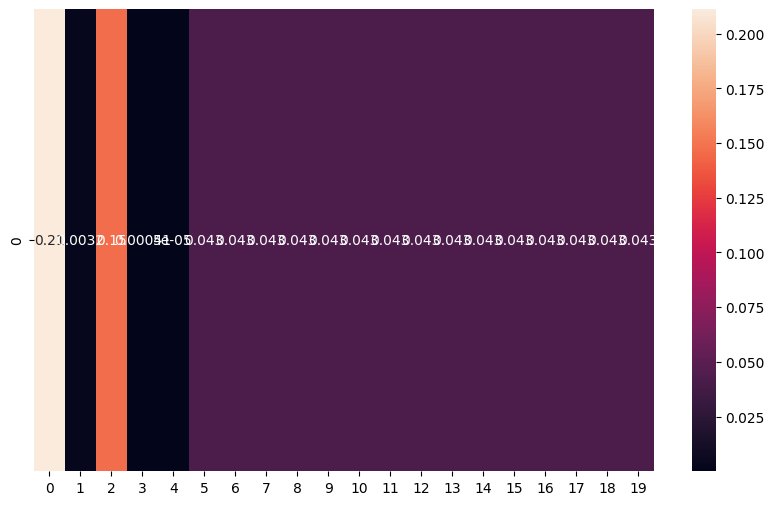

Text: nó dở quá
Prediction: 0
Attention weights: tensor([[9.9360e-01, 5.9030e-03, 4.7858e-04, 1.3024e-06, 1.3024e-06, 1.3024e-06,
         1.3024e-06, 1.3024e-06, 1.3024e-06, 1.3024e-06, 1.3024e-06, 1.3024e-06,
         1.3024e-06, 1.3024e-06, 1.3024e-06, 1.3024e-06, 1.3024e-06, 1.3024e-06,
         1.3024e-06, 1.3024e-06]], grad_fn=<SoftmaxBackward0>)


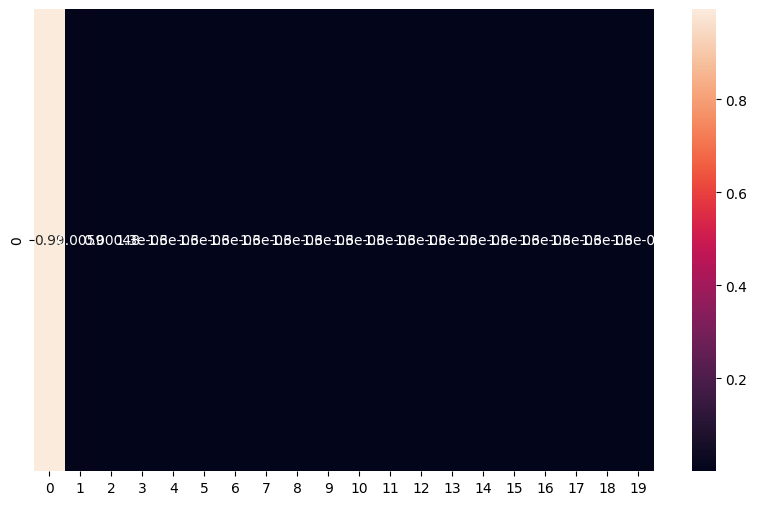

Text: môn học này rất hay
Prediction: 2
Attention weights: tensor([[5.3153e-05, 1.0966e-02, 1.7326e-06, 9.6756e-01, 9.7702e-03, 7.7645e-04,
         7.7645e-04, 7.7645e-04, 7.7645e-04, 7.7645e-04, 7.7645e-04, 7.7645e-04,
         7.7645e-04, 7.7645e-04, 7.7645e-04, 7.7645e-04, 7.7645e-04, 7.7645e-04,
         7.7645e-04, 7.7645e-04]], grad_fn=<SoftmaxBackward0>)


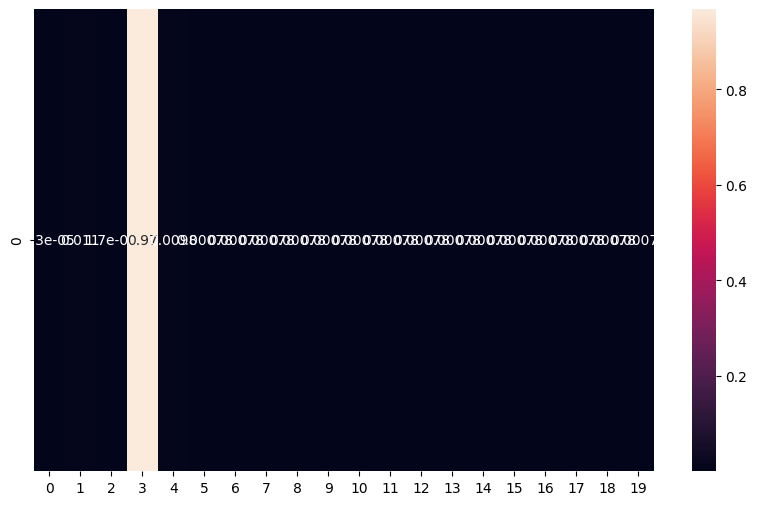

Text: giảng viên dạy chán
Prediction: 0
Attention weights: tensor([[9.7669e-04, 2.8378e-03, 1.8240e-04, 8.1422e-01, 1.1361e-02, 1.1361e-02,
         1.1361e-02, 1.1361e-02, 1.1361e-02, 1.1361e-02, 1.1361e-02, 1.1361e-02,
         1.1361e-02, 1.1361e-02, 1.1361e-02, 1.1361e-02, 1.1361e-02, 1.1361e-02,
         1.1361e-02, 1.1361e-02]], grad_fn=<SoftmaxBackward0>)


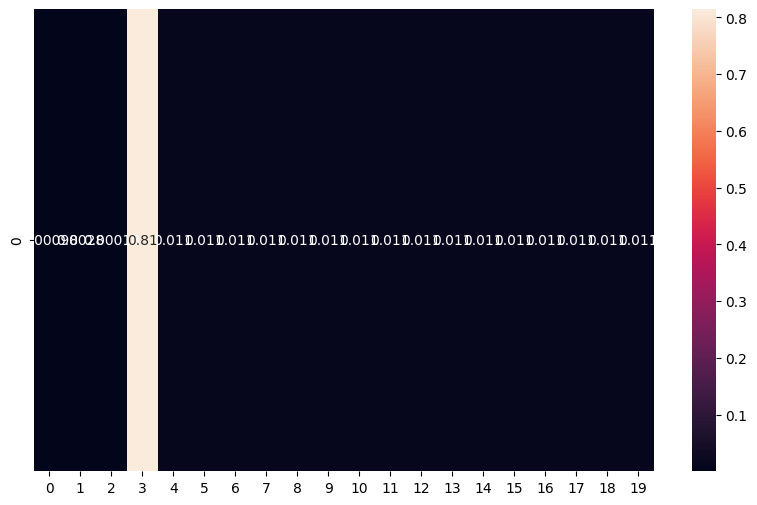

In [ ]:
predict_attention_model("tôi thích học môn này",model)
predict_attention_model("nó dở quá",model)
predict_attention_model("môn học này rất hay",model)
predict_attention_model("giảng viên dạy chán",model)

# Homework

## DISCUSSION QUESTIONS

1️⃣ Why does Attention improve model performance?

2️⃣ What happens if all attention weights are equal?

3️⃣ Why do we use the softmax function?

4️⃣ What are the roles of Query, Key, and Value?

5️⃣ Does Attention replace RNNs?

## 🧪 Experiments & Exercises

Overall Pipeline:

Data → Tokenization → Baseline Seq2Seq → Attention → Training → Evaluation → Visualization

### Dataset

We will use:

HuggingFace dataset: opus100 (en-vi)
```python
from datasets import load_dataset

dataset = load_dataset("opus100", "en-vi")
```

In [ ]:
dataset_homework = load_dataset("opus100", "en-vi")

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1000000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
dataset_homework["test"][0]

{'translation': {'en': 'We are in a dive.', 'vi': 'Chúng ta đang lao xuống.'}}



### Part 1: Data Preprocessing

#### Requirements
- Inspect dataset
- Tokenization
  - Lowercase text
  - Split into tokens (use basic or torchtext/spacy)

- Build vocab for:
  - English (source)
  - Vietnamese (target)
  
  Include: \<pad>, \<sos>, \<eos>, \<unk>
  - CREATE padding_mask:
    mask = (input != \<pad>)
    

- Numericalization + Padding
  - Convert tokens → indices
  - Pad sequences to same length


- Analysis Questions
  - What happens when vocabulary size increases?
  - How does padding length affect training speed?
  - Why do we need \<sos> and \<eos>?

After processing (example)
  > encoder_input  = [\<sos>, i, love, you, \<eos>, \<pad>, ...]
  >
  > decoder_input  = [\<sos>, tôi, yêu, bạn, \<eos>, \<pad>, ...]
  >
  > target         = [tôi, yêu, bạn, \<eos>, \<pad>, ...]
  >
  > (target = decoder_input shifted left)

### Part 2: Baseline Model (NO Attention)
input_token → embedding → Encoder → final hidden → Decoder → output

```python
CLASS Seq2Seq:
    INIT(encoder, decoder):
        self.encoder = encoder
        self.decoder = decoder
    FORWARD(src, trg, teacher_forcing_ratio):
        hidden, cell = encoder(src)
        input_token = <sos>
        FOR t in range(1 → target_length):
            prediction, hidden, cell = decoder(input_token, hidden, cell)
            STORE prediction
            use_teacher = random() < teacher_forcing_ratio
            IF use_teacher:
                input_token = trg[t]
            ELSE:
                input_token = argmax(prediction)
        RETURN all_predictions
```

#### Requirements
- Implement a Seq2Seq model using LSTM (define 2 module)
  ``` using torch.nn.LSTM ```
  - Encoder (LSTM)
  - Decoder (LSTM)
  - Seq2Seq Wrapper
- Experiments
  - Change hidden size (128 → 512)
  - Change embedding size (100 → 300)
- Analysis Questions
  - Why does the baseline struggle with long sentences?
  - What information is lost in encoder hidden state?


### Part 3: Attention Mechanism
input_token → embedding → Encoder → all hidden states → Attention → Decoder → output

```python
CLASS Seq2SeqAttention:
    FORWARD(src, trg, teacher_forcing_ratio):
        encoder_outputs, hidden, cell = encoder(src)
        input_token = <sos>
        FOR t in range(1 → target_length):
            prediction, hidden, cell, attn = decoder(
                input_token, hidden, cell, encoder_outputs
            )
            STORE prediction
            STORE attention weights
            use_teacher = random() < teacher_forcing_ratio
            IF use_teacher:
                input_token = trg[t]
            ELSE:
                input_token = argmax(prediction)
        RETURN predictions, attention_weights
```

#### Requirements
- Define Attention Components
 - We implement Additive Attention (Bahdanau)
    - Step 1: Compute Attention Score
      - Query = Decoder hidden state
      - Key = Encoder outputs
      - Value = Encoder outputs
    - Compute Context Vector
  - Update Decoder: Decoder input = embedding + context_vector

- Experiments
  - Replace additive → dot-product attention


### Part 4: Training
#### Requirements
- Train:
  - Baseline model
  - Attention model

- Training Setup:
  - Use batching [batch_size, seq_len]
  - Use CrossEntropyLoss (ignore_index = \<pad>)
  - Optimizer (e.g., Adam)

- Logging:
  - Training loss
  - Validation loss

- Experiments:
  - Teacher forcing ratio: 0.5 vs 1.0
  - Learning rate changes

- Analysis Questions:
  - Which model converges faster and why?
  - Does attention improve generalization on long sequences?
  - How does teacher forcing ratio affect training stability?

### Part 5: Evaluation
#### Requirements
- Generate Translations
  ```python
  def translate_sentence(sentence, max_len):
    # encode → decode step-by-step
    ...
    return predicted_tokens
  
  ```
- Compare Outputs (2 models)
- Experiments
  - Try short vs long sentences
  - Try rare words
- Analysis Questions
  - Which model handles long sentences better and why?
  - How does attention help with rare or unknown words?
  - What types of errors does each model make?

### Part 6: Visualization (🔥 Important)
#### Requirements
- Visualize attention weights using heatmap
  - X-axis: source tokens
  - Y-axis: target tokens
  - Attention weights are normalized (softmax)

- Experiments:
  - Compare attention maps: good vs bad translations

- Analysis Questions:
  - Does attention align words correctly?
  - What patterns do you observe?
  - When does attention fail?

### Part 7: Shor Report
#### Requirements

Write a short report including:

1. Problem Description
   - Describe the translation task

2. Model Setup
   - Baseline vs Attention
   - Key hyperparameters

3. Experimental Results
   - Training & validation loss
   - Example translations

4. Attention Analysis
   - Visualization examples
   - Observations

5. Discussion
   - Strengths and weaknesses of each model
   - Common errors
   - Effect of teacher forcing

6. Conclusion
   - Key takeaways